# **PHASE:3**

## Cell 1 — Install / import dependencies

In [1]:

import subprocess, sys

def _pip_install(pkg):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=False)

for pkg in ["albumentations", "ultralytics", "openpyxl"]:
    _pip_install(pkg)

import torch
print("Torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
DEVICE = 0 if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 3.6 MB/s eta 0:00:00
Torch: 2.10.0+cu128 | CUDA available: True
GPU: Tesla T4
Using device: 0


## Cell 2 — Configuration (all tunable parameters live here)

In [2]:
import os, random
import numpy as np

SEED = 42
IMG_SIZE = 640
CONF_THRESHOLD = 0.25   
EVAL_CONF = 0.001       
IOU_THRESHOLD = 0.70

MODEL_NAME = "YOLO11s"

# Severity parameters -- loosely grounded in the ImageNet-C corruption benchmark
# conventions (Hendrycks & Dietterich, 2019). Change these freely; every
# downstream cell reads from these dicts.
GAUSSIAN_NOISE_STD = {1: 0.03, 2: 0.06, 3: 0.10, 4: 0.15}   # std, fraction of [0,1] pixel range
MOTION_BLUR_KERNEL = {1: 5,    2: 9,    3: 13,   4: 17}     # odd kernel size in pixels
LOW_LIGHT_FACTOR   = {1: 0.80, 2: 0.60, 3: 0.40, 4: 0.20}   # HSV V-channel scale factor (lower = darker)

OUTPUT_ROOT  = "/kaggle/working/phase3_robustness"
DEGRADED_DIR = os.path.join(OUTPUT_ROOT, "degraded_datasets")
RESULTS_DIR  = os.path.join(OUTPUT_ROOT, "results")
PLOTS_DIR    = os.path.join(OUTPUT_ROOT, "plots")
QUAL_DIR     = os.path.join(OUTPUT_ROOT, "qualitative_examples")
LOGS_DIR     = os.path.join(OUTPUT_ROOT, "logs")

for d in [OUTPUT_ROOT, DEGRADED_DIR, RESULTS_DIR, PLOTS_DIR, QUAL_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)

DPI = 300
N_QUALITATIVE_SAMPLES = 5

random.seed(SEED)
np.random.seed(SEED)

print("Configuration loaded.")
print("Gaussian noise std levels:", GAUSSIAN_NOISE_STD)
print("Motion blur kernel levels:", MOTION_BLUR_KERNEL)
print("Low-light factor levels :", LOW_LIGHT_FACTOR)

Configuration loaded.
Gaussian noise std levels: {1: 0.03, 2: 0.06, 3: 0.1, 4: 0.15}
Motion blur kernel levels: {1: 5, 2: 9, 3: 13, 4: 17}
Low-light factor levels : {1: 0.8, 2: 0.6, 3: 0.4, 4: 0.2}


In [3]:
!pip install -q roboflow

from roboflow import Roboflow

ROBOFLOW_API_KEY = "eFz0r5rdHpUUABPht8JV"  

WORKSPACE = "md-s-workspace"
PROJECT   = "fire_smoke_detection-tmqte"
VERSION   = 4

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
dataset = project.version(VERSION).download("yolov11")

DATASET_DIR = dataset.location
print("Dataset downloaded to:", DATASET_DIR)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.3/302.3 kB 5.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 30.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 88.9 MB/s eta 0:00:00:00:01
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to fire_smoke_detection-4 in yolov11:: 100%|██████████| 23025/23025 [00:02<00:00, 8598.18it/s] 


Dataset downloaded to: /kaggle/working/fire_smoke_detection-4


## Cell 3 — Find and verify dataset / model paths (no path is assumed blindly)

In [4]:
import glob

def find_files(pattern, roots=("/kaggle/input", "/kaggle/working")):
    hits = []
    for root in roots:
        hits.extend(glob.glob(os.path.join(root, pattern), recursive=True))
    return sorted(set(hits))

print("Searching for best.pt weight files...")
candidate_models = find_files("**/best.pt")
for p in candidate_models:
    print(" -", p)

if not candidate_models:
    raise FileNotFoundError(
        "No best.pt found under /kaggle/input or /kaggle/working. "
        "Set BEST_MODEL_PATH manually in this cell."
    )

# >>> If auto-detection picks the wrong file, override manually here <<<
BEST_MODEL_PATH = candidate_models[0]
print("\nSelected model path:", BEST_MODEL_PATH)

print("\nSearching for test image directories...")
candidate_test_img_dirs = find_files("**/test/images")
for p in candidate_test_img_dirs:
    print(" -", p)

if not candidate_test_img_dirs:
    raise FileNotFoundError(
        "No 'test/images' directory found. Inspect /kaggle/input structure manually "
        "and set TEST_IMAGES_DIR / TEST_LABELS_DIR below."
    )

# >>> Override manually here if the auto-detected split is wrong <<<
TEST_IMAGES_DIR = candidate_test_img_dirs[0]
TEST_LABELS_DIR = TEST_IMAGES_DIR.replace("images", "labels")

print("\nSelected TEST_IMAGES_DIR:", TEST_IMAGES_DIR)
print("Selected TEST_LABELS_DIR:", TEST_LABELS_DIR)
print("TEST_LABELS_DIR exists:", os.path.isdir(TEST_LABELS_DIR))

print("\nSearching for a data.yaml (for class names)...")
candidate_yaml = find_files("**/data.yaml")
print("data.yaml candidates found:", candidate_yaml)

CLASS_NAMES = ["Fire", "Smoke"]  # fallback if no usable data.yaml is found
DATA_YAML_SOURCE = None
if candidate_yaml:
    import yaml
    for yml in candidate_yaml:
        try:
            with open(yml) as f:
                y = yaml.safe_load(f)
            if y and "names" in y:
                names = y["names"]
                CLASS_NAMES = list(names.values()) if isinstance(names, dict) else list(names)
                DATA_YAML_SOURCE = yml
                break
        except Exception as e:
            print(f"Could not parse {yml}: {e}")

print("\nUsing class names:", CLASS_NAMES, "(source:", DATA_YAML_SOURCE, ")")
NUM_CLASSES = len(CLASS_NAMES)

Searching for best.pt weight files...
 - /kaggle/input/datasets/sadiahaiderjaima/yolov11s/best.pt

Selected model path: /kaggle/input/datasets/sadiahaiderjaima/yolov11s/best.pt

Searching for test image directories...
 - /kaggle/working/fire_smoke_detection-4/test/images

Selected TEST_IMAGES_DIR: /kaggle/working/fire_smoke_detection-4/test/images
Selected TEST_LABELS_DIR: /kaggle/working/fire_smoke_detection-4/test/labels
TEST_LABELS_DIR exists: True

Searching for a data.yaml (for class names)...
data.yaml candidates found: ['/kaggle/working/fire_smoke_detection-4/data.yaml']

Using class names: ['Fire', 'Smoke'] (source: /kaggle/working/fire_smoke_detection-4/data.yaml )


## Cell 4 — Dataset integrity check (original test set, untouched)

In [5]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def list_images(d):
    return sorted([f for f in os.listdir(d) if f.lower().endswith(IMG_EXTS)])

orig_images = list_images(TEST_IMAGES_DIR)
orig_labels = (
    sorted([f for f in os.listdir(TEST_LABELS_DIR) if f.endswith(".txt")])
    if os.path.isdir(TEST_LABELS_DIR) else []
)

print(f"Original test images found : {len(orig_images)}")
print(f"Original test label files : {len(orig_labels)}")

images_without_labels = [
    f for f in orig_images
    if not os.path.exists(os.path.join(TEST_LABELS_DIR, os.path.splitext(f)[0] + ".txt"))
]
print(f"Images without a label file (expected for background/non-fire images): {len(images_without_labels)}")

if len(orig_images) == 0:
    raise RuntimeError("No test images found -- cannot proceed with Phase 3.")

orphan_labels = [
    f for f in orig_labels
    if not any(os.path.exists(os.path.join(TEST_IMAGES_DIR, os.path.splitext(f)[0] + ext)) for ext in IMG_EXTS)
]
if orphan_labels:
    print(f"WARNING: {len(orphan_labels)} label files have no matching image file:")
    for f in orphan_labels[:10]:
        print("  -", f)
else:
    print("No orphan label files detected.")

integrity_report = {
    "original_test_image_count": len(orig_images),
    "original_test_label_count": len(orig_labels),
    "images_without_labels": len(images_without_labels),
    "orphan_labels": len(orphan_labels),
}

Original test images found : 1715
Original test label files : 1715
Images without a label file (expected for background/non-fire images): 0
No orphan label files detected.


## Cell 5 — Load the trained YOLO11s model (no retraining)

In [6]:
from ultralytics import YOLO

print(f"Loading trained {MODEL_NAME} weights from: {BEST_MODEL_PATH}")
model = YOLO(BEST_MODEL_PATH)
print("Model loaded. Task:", model.task)

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Loading trained YOLO11s weights from: /kaggle/input/datasets/sadiahaiderjaima/yolov11s/best.pt
Model loaded. Task: detect


## Cell 6 — Clean test-set baseline evaluation

**Methodological note (conflict flagged per your item 6):** Ultralytics' `val()` computes
mAP by integrating the full precision-recall curve, which requires a low confidence
threshold (`EVAL_CONF = 0.001`) so low-confidence detections aren't discarded before the
curve is built. Running validation with `CONF_THRESHOLD = 0.25` directly would silently
truncate that curve and under-report mAP. So `EVAL_CONF` is used inside every `val()` call
below; `CONF_THRESHOLD` is kept only as a config value for any future single-operating-point
reporting you may want, and is not used in this evaluation loop.

In [7]:
import yaml as pyyaml

def make_data_yaml(images_dir, yaml_path, names):
    split_root = os.path.dirname(images_dir)  # parent of the 'images' folder
    data = {
        "path": split_root,
        "train": "images",  # required key by Ultralytics schema, unused for val-only runs
        "val": "images",
        "names": {i: n for i, n in enumerate(names)},
    }
    with open(yaml_path, "w") as f:
        pyyaml.dump(data, f)
    return yaml_path

def evaluate_dataset(images_dir, name, conf=EVAL_CONF, iou=IOU_THRESHOLD, imgsz=IMG_SIZE):
    yaml_path = os.path.join(LOGS_DIR, f"data_{name}.yaml")
    make_data_yaml(images_dir, yaml_path, CLASS_NAMES)
    metrics = model.val(
        data=yaml_path,
        imgsz=imgsz,
        conf=conf,
        iou=iou,
        split="val",
        device=DEVICE,
        verbose=False,
        plots=False,
        save_json=False,
    )
    return {
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50_95": float(metrics.box.map),
    }

print("Running baseline evaluation on the CLEAN test set...")
clean_metrics = evaluate_dataset(TEST_IMAGES_DIR, "clean")
print("Clean baseline metrics:", clean_metrics)

Running baseline evaluation on the CLEAN test set...
Ultralytics 8.4.130 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO11s summary (fused): 101 layers, 9,413,574 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 963.9±404.0 MB/s, size: 37.1 KB)
val: Scanning /kaggle/working/fire_smoke_detection-4/test/labels... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 1.1Kit/s 1.6s0.1s
val: New cache created: /kaggle/working/fire_smoke_detection-4/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.3it/s 20.2s0.2s
                   all       1715       2790      0.869      0.763      0.828      0.625
Speed: 0.8ms preprocess, 8.1ms inference, 0.0ms loss, 0.6ms postprocess per image
Clean baseline metrics: {'Precision': 0.8693614303676278, 'Recall': 0.7629341745638824, 'mAP50': 0.8280397930800434, 'mAP50_95': 0.6254836129631938}


## Cell 7 — Generate Gaussian Noise degraded datasets

**Note on Albumentations version instability:** `A.GaussNoise` / `A.MotionBlur` parameter
names (`var_limit` vs `std_range`, `blur_limit` format) have changed across Albumentations
releases and can silently break on a Kaggle environment update. To guarantee exact,
version-independent reproducibility, the transforms below are implemented as plain
numpy/cv2 functions wrapped in `A.Lambda` inside an `A.Compose` pipeline -- still an
Albumentations pipeline, but with full control over the exact operation.

In [8]:
import cv2, shutil
import albumentations as A

def copy_label_if_exists(fname, out_labels_dir):
    base = os.path.splitext(fname)[0] + ".txt"
    src = os.path.join(TEST_LABELS_DIR, base)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(out_labels_dir, base))

def gaussian_noise_transform(std):
    def _fn(image, **kwargs):
        img = image.astype(np.float32) / 255.0
        noise = np.random.normal(0.0, std, img.shape).astype(np.float32)
        noisy = np.clip(img + noise, 0.0, 1.0)
        return (noisy * 255.0).astype(np.uint8)
    return A.Compose([A.Lambda(image=_fn, p=1.0)])

def motion_blur_transform(k):
    def _fn(image, **kwargs):
        kernel = np.zeros((k, k), dtype=np.float32)
        kernel[k // 2, :] = 1.0
        kernel /= k
        return cv2.filter2D(image, -1, kernel)
    return A.Compose([A.Lambda(image=_fn, p=1.0)])

def low_light_transform(factor):
    def _fn(image, **kwargs):
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV).astype(np.float32)
        hsv[:, :, 2] = np.clip(hsv[:, :, 2] * factor, 0, 255)
        return cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2RGB)
    return A.Compose([A.Lambda(image=_fn, p=1.0)])

def generate_degraded_set(severities_dict, transform_factory, out_subdir):
    print(f"\nGenerating {out_subdir} datasets...")
    counts = {}
    for sev, param in severities_dict.items():
        out_images = os.path.join(DEGRADED_DIR, out_subdir, f"severity_{sev}", "images")
        out_labels = os.path.join(DEGRADED_DIR, out_subdir, f"severity_{sev}", "labels")
        os.makedirs(out_images, exist_ok=True)
        os.makedirs(out_labels, exist_ok=True)
        transform = transform_factory(param)
        n_written = 0
        for fname in orig_images:
            img_path = os.path.join(TEST_IMAGES_DIR, fname)
            img = cv2.imread(img_path)
            if img is None:
                print(f"  WARNING: could not read {img_path}, skipping.")
                continue
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            degraded = transform(image=img_rgb)["image"]
            degraded_bgr = cv2.cvtColor(degraded, cv2.COLOR_RGB2BGR)
            cv2.imwrite(os.path.join(out_images, fname), degraded_bgr)
            copy_label_if_exists(fname, out_labels)
            n_written += 1
        counts[sev] = n_written
        print(f"  Severity {sev} ({param}): {n_written} images written.")
    return counts

# Gaussian noise uses np.random -- run this cell before Motion Blur / Low Light so that,
# given the fixed SEED set in Cell 2, results stay reproducible across kernel restarts.
gaussian_counts = generate_degraded_set(GAUSSIAN_NOISE_STD, gaussian_noise_transform, "gaussian_noise")


Generating gaussian_noise datasets...
  Severity 1 (0.03): 1715 images written.
  Severity 2 (0.06): 1715 images written.
  Severity 3 (0.1): 1715 images written.
  Severity 4 (0.15): 1715 images written.


## Cell 8 — Generate Motion Blur degraded datasets


In [9]:
motion_blur_counts = generate_degraded_set(MOTION_BLUR_KERNEL, motion_blur_transform, "motion_blur")


Generating motion_blur datasets...
  Severity 1 (5): 1715 images written.
  Severity 2 (9): 1715 images written.
  Severity 3 (13): 1715 images written.
  Severity 4 (17): 1715 images written.


## Cell 9 — Generate Low-Light degraded datasets

In [11]:
low_light_counts = generate_degraded_set(LOW_LIGHT_FACTOR, low_light_transform, "low_light")


Generating low_light datasets...
  Severity 1 (0.8): 1715 images written.
  Severity 2 (0.6): 1715 images written.
  Severity 3 (0.4): 1715 images written.
  Severity 4 (0.2): 1715 images written.


## Cell 10 — Evaluate all degraded datasets (same model, same settings as Cell 6)

In [12]:
results_rows = []

def add_result(degradation_label, severity, metrics_dict, param_value):
    results_rows.append({
        "Degradation": degradation_label,
        "Severity": severity,
        "Precision": metrics_dict["Precision"],
        "Recall": metrics_dict["Recall"],
        "mAP50": metrics_dict["mAP50"],
        "mAP50_95": metrics_dict["mAP50_95"],
        "SeverityParam": param_value,
    })

add_result("Clean", 0, clean_metrics, None)

for sev, std in GAUSSIAN_NOISE_STD.items():
    img_dir = os.path.join(DEGRADED_DIR, "gaussian_noise", f"severity_{sev}", "images")
    print(f"Evaluating Gaussian Noise severity {sev}...")
    add_result("Gaussian Noise", sev, evaluate_dataset(img_dir, f"gaussian_noise_sev{sev}"), std)

for sev, k in MOTION_BLUR_KERNEL.items():
    img_dir = os.path.join(DEGRADED_DIR, "motion_blur", f"severity_{sev}", "images")
    print(f"Evaluating Motion Blur severity {sev}...")
    add_result("Motion Blur", sev, evaluate_dataset(img_dir, f"motion_blur_sev{sev}"), k)

for sev, f in LOW_LIGHT_FACTOR.items():
    img_dir = os.path.join(DEGRADED_DIR, "low_light", f"severity_{sev}", "images")
    print(f"Evaluating Low-Light severity {sev}...")
    add_result("Low Light", sev, evaluate_dataset(img_dir, f"low_light_sev{sev}"), f)

print("\nAll evaluations complete.")

Evaluating Gaussian Noise severity 1...
Ultralytics 8.4.130 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2030.1±772.8 MB/s, size: 173.6 KB)
val: Scanning /kaggle/working/phase3_robustness/degraded_datasets/gaussian_noise/severity_1/labels.cache... 1715 images, 287 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1715/1715 104.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 108/108 5.2it/s 20.7s0.2s
                   all       1715       2790      0.856      0.716      0.784      0.591
Speed: 0.8ms preprocess, 9.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Evaluating Gaussian Noise severity 2...
Ultralytics 8.4.130 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2730.2±758.4 MB/s, size: 220.2 KB)
val: Scanning /kaggle/working/phase3_robustness/degraded_datasets/gaussian_noise/sev

## Cell 11 — Build results dataframe

In [13]:
import pandas as pd
results_df = pd.DataFrame(results_rows)
results_df

,Degradation,Severity,Precision,Recall,mAP50,mAP50_95,SeverityParam
0,Clean,0,0.869361,0.762934,0.828040,0.625484,NaN
1,Gaussian Noise,1,0.855555,0.716088,0.783998,0.590691,0.03
2,Gaussian Noise,2,0.775929,0.576955,0.636428,0.484954,0.06
3,Gaussian Noise,3,0.783000,0.465214,0.516404,0.402309,0.10
4,Gaussian Noise,4,0.664069,0.356103,0.370867,0.276117,0.15
5,Motion Blur,1,0.877249,0.756887,0.827109,0.624187,5.00
6,Motion Blur,2,0.871974,0.731861,0.809976,0.603373,9.00
7,Motion Blur,3,0.870828,0.690419,0.775272,0.566320,13.00
8,Motion Blur,4,0.817626,0.657045,0.724563,0.514225,17.00
9,Low Light,1,0.875656,0.758979,0.826797,0.627010,0.80


## Cell 12 — Calculate performance degradation relative to clean baseline

In [14]:
clean_row = results_df[results_df["Degradation"] == "Clean"].iloc[0]

def pct_drop(row, col):
    if row["Degradation"] == "Clean":
        return 0.0
    base = clean_row[col]
    if base == 0:
        return np.nan
    return ((base - row[col]) / base) * 100.0

for col in ["mAP50", "mAP50_95", "Precision", "Recall"]:
    results_df[f"{col}_Drop_Percentage"] = results_df.apply(lambda r, c=col: pct_drop(r, c), axis=1)

results_df

,Degradation,Severity,Precision,Recall,mAP50,mAP50_95,SeverityParam,mAP50_Drop_Percentage,mAP50_95_Drop_Percentage,Precision_Drop_Percentage,Recall_Drop_Percentage
0,Clean,0,0.869361,0.762934,0.828040,0.625484,NaN,0.000000,0.000000,0.000000,0.000000
1,Gaussian Noise,1,0.855555,0.716088,0.783998,0.590691,0.03,5.318779,5.562553,1.588136,6.140241
2,Gaussian Noise,2,0.775929,0.576955,0.636428,0.484954,0.06,23.140352,22.467346,10.747245,24.376770
3,Gaussian Noise,3,0.783000,0.465214,0.516404,0.402309,0.10,37.635305,35.680276,9.933874,39.023097
4,Gaussian Noise,4,0.664069,0.356103,0.370867,0.276117,0.15,55.211498,55.855476,23.614113,53.324539
5,Motion Blur,1,0.877249,0.756887,0.827109,0.624187,5.00,0.112390,0.207279,-0.907307,0.792578
6,Motion Blur,2,0.871974,0.731861,0.809976,0.603373,9.00,2.181525,3.534972,-0.300492,4.072826
7,Motion Blur,3,0.870828,0.690419,0.775272,0.566320,13.00,6.372640,9.458930,-0.168638,9.504715
8,Motion Blur,4,0.817626,0.657045,0.724563,0.514225,17.00,12.496632,17.787620,5.950919,13.879217
9,Low Light,1,0.875656,0.758979,0.826797,0.627010,0.80,0.150099,-0.244036,-0.723990,0.518367


## Cell 13 — Publication-quality plots

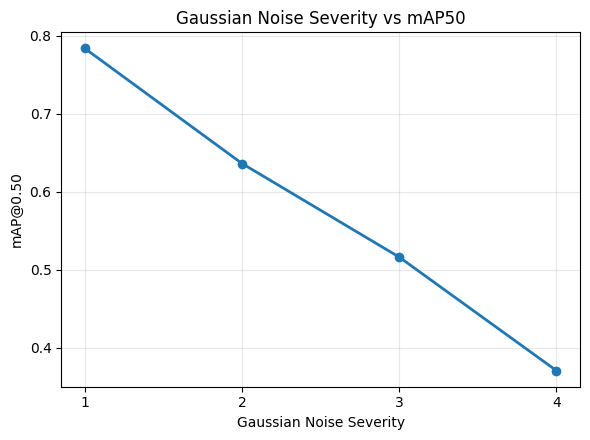

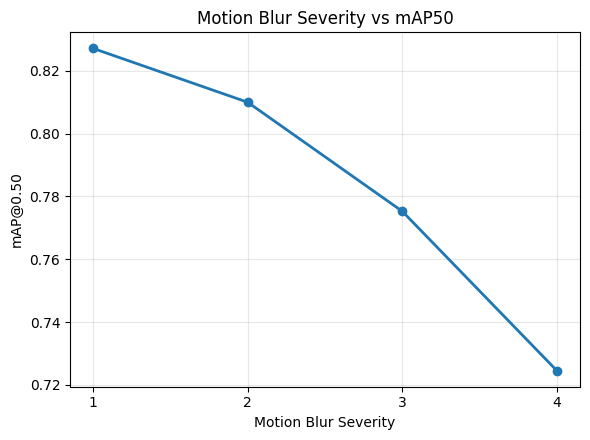

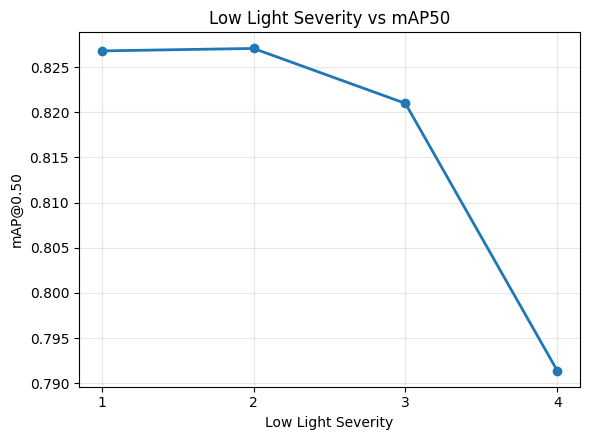

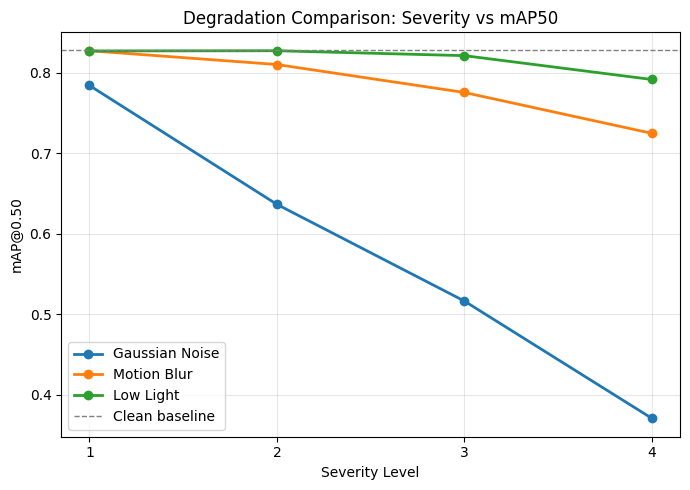

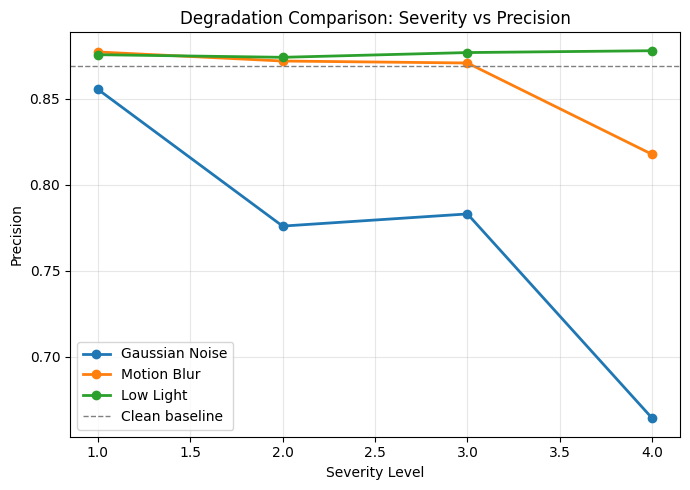

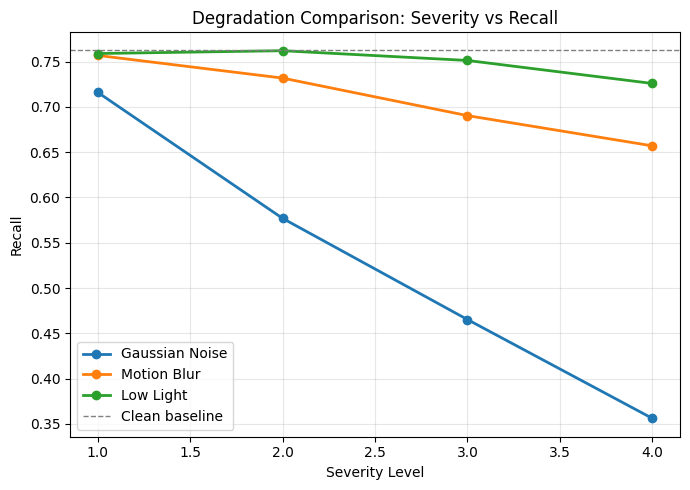

Plots saved to: /kaggle/working/phase3_robustness/plots


In [15]:
import matplotlib.pyplot as plt

def plot_single(degradation_name, filename_prefix):
    sub = results_df[results_df["Degradation"] == degradation_name]
    plt.figure(figsize=(6, 4.5))
    plt.plot(sub["Severity"], sub["mAP50"], marker="o", linewidth=2)
    plt.title(f"{degradation_name} Severity vs mAP50")
    plt.xlabel(f"{degradation_name} Severity")
    plt.ylabel("mAP@0.50")
    plt.xticks(sub["Severity"])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"{filename_prefix}_mAP50.{ext}"), dpi=DPI)
    plt.show()
    plt.close()

plot_single("Gaussian Noise", "gaussian_noise")
plot_single("Motion Blur", "motion_blur")
plot_single("Low Light", "low_light")

plt.figure(figsize=(7, 5))
for deg in ["Gaussian Noise", "Motion Blur", "Low Light"]:
    sub = results_df[results_df["Degradation"] == deg]
    plt.plot(sub["Severity"], sub["mAP50"], marker="o", linewidth=2, label=deg)
plt.axhline(clean_row["mAP50"], color="gray", linestyle="--", linewidth=1, label="Clean baseline")
plt.title("Degradation Comparison: Severity vs mAP50")
plt.xlabel("Severity Level")
plt.ylabel("mAP@0.50")
plt.xticks(sorted(results_df[results_df["Degradation"] != "Clean"]["Severity"].unique()))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
for ext in ("png", "pdf"):
    plt.savefig(os.path.join(PLOTS_DIR, f"degradation_comparison_mAP50.{ext}"), dpi=DPI)
plt.show()
plt.close()

for metric, label in [("Precision", "Precision"), ("Recall", "Recall")]:
    plt.figure(figsize=(7, 5))
    for deg in ["Gaussian Noise", "Motion Blur", "Low Light"]:
        sub = results_df[results_df["Degradation"] == deg]
        plt.plot(sub["Severity"], sub[metric], marker="o", linewidth=2, label=deg)
    plt.axhline(clean_row[metric], color="gray", linestyle="--", linewidth=1, label="Clean baseline")
    plt.title(f"Degradation Comparison: Severity vs {label}")
    plt.xlabel("Severity Level")
    plt.ylabel(label)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    for ext in ("png", "pdf"):
        plt.savefig(os.path.join(PLOTS_DIR, f"degradation_comparison_{metric.lower()}.{ext}"), dpi=DPI)
    plt.show()
    plt.close()

print("Plots saved to:", PLOTS_DIR)

## Cell 14 — Representative qualitative examples (original vs degraded, side by side)

In [16]:
sample_files = orig_images[:N_QUALITATIVE_SAMPLES]

def save_side_by_side(orig_path, degraded_path, out_path, title_right):
    orig = cv2.cvtColor(cv2.imread(orig_path), cv2.COLOR_BGR2RGB)
    deg = cv2.cvtColor(cv2.imread(degraded_path), cv2.COLOR_BGR2RGB)
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(orig); axes[0].set_title("Original"); axes[0].axis("off")
    axes[1].imshow(deg); axes[1].set_title(title_right); axes[1].axis("off")
    plt.tight_layout()
    plt.savefig(out_path, dpi=DPI)
    plt.close()

for deg_name, sev_dict, subdir in [
    ("Gaussian Noise", GAUSSIAN_NOISE_STD, "gaussian_noise"),
    ("Motion Blur", MOTION_BLUR_KERNEL, "motion_blur"),
    ("Low Light", LOW_LIGHT_FACTOR, "low_light"),
]:
    out_dir = os.path.join(QUAL_DIR, subdir)
    os.makedirs(out_dir, exist_ok=True)
    for sev in sev_dict:
        for fname in sample_files:
            orig_path = os.path.join(TEST_IMAGES_DIR, fname)
            degraded_path = os.path.join(DEGRADED_DIR, subdir, f"severity_{sev}", "images", fname)
            if not os.path.exists(degraded_path):
                continue
            out_path = os.path.join(out_dir, f"sev{sev}_{os.path.splitext(fname)[0]}.png")
            save_side_by_side(orig_path, degraded_path, out_path, f"{deg_name} (severity {sev})")

print("Qualitative examples saved to:", QUAL_DIR)

Qualitative examples saved to: /kaggle/working/phase3_robustness/qualitative_examples


## Cell 15 — Save CSV / Excel / config

In [17]:
import json

csv_path = os.path.join(RESULTS_DIR, "phase3_results.csv")
results_df.to_csv(csv_path, index=False)

summary_df = results_df.groupby("Degradation").agg(
    mean_mAP50=("mAP50", "mean"),
    mean_mAP50_95=("mAP50_95", "mean"),
    mean_Precision=("Precision", "mean"),
    mean_Recall=("Recall", "mean"),
    mean_mAP50_Drop_Percentage=("mAP50_Drop_Percentage", "mean"),
).reset_index()
summary_csv_path = os.path.join(RESULTS_DIR, "phase3_summary.csv")
summary_df.to_csv(summary_csv_path, index=False)

xlsx_path = os.path.join(RESULTS_DIR, "phase3_results.xlsx")
with pd.ExcelWriter(xlsx_path) as writer:
    results_df.to_excel(writer, sheet_name="full_results", index=False)
    summary_df.to_excel(writer, sheet_name="summary", index=False)

config = {
    "model_path": BEST_MODEL_PATH,
    "model_name": MODEL_NAME,
    "img_size": IMG_SIZE,
    "conf_threshold_reported": CONF_THRESHOLD,
    "eval_conf_used_for_map": EVAL_CONF,
    "iou_threshold": IOU_THRESHOLD,
    "seed": SEED,
    "class_names": CLASS_NAMES,
    "degradation_types": ["gaussian_noise", "motion_blur", "low_light"],
    "severity_params": {
        "gaussian_noise_std": GAUSSIAN_NOISE_STD,
        "motion_blur_kernel": MOTION_BLUR_KERNEL,
        "low_light_factor": LOW_LIGHT_FACTOR,
    },
    "test_images_dir": TEST_IMAGES_DIR,
    "test_labels_dir": TEST_LABELS_DIR,
    "output_root": OUTPUT_ROOT,
}
config_path = os.path.join(OUTPUT_ROOT, "phase3_config.json")
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)

integrity_report.update({
    "gaussian_noise_counts": gaussian_counts,
    "motion_blur_counts": motion_blur_counts,
    "low_light_counts": low_light_counts,
})
integrity_path = os.path.join(LOGS_DIR, "dataset_integrity_report.json")
with open(integrity_path, "w") as f:
    json.dump(integrity_report, f, indent=2)

print("Saved:", csv_path)
print("Saved:", summary_csv_path)
print("Saved:", xlsx_path)
print("Saved:", config_path)
print("Saved:", integrity_path)

Saved: /kaggle/working/phase3_robustness/results/phase3_results.csv
Saved: /kaggle/working/phase3_robustness/results/phase3_summary.csv
Saved: /kaggle/working/phase3_robustness/results/phase3_results.xlsx
Saved: /kaggle/working/phase3_robustness/phase3_config.json
Saved: /kaggle/working/phase3_robustness/logs/dataset_integrity_report.json


## Cell 16 — Final verification

In [18]:
print("=== Final Verification ===")
for degradation, counts in [
    ("Gaussian Noise", gaussian_counts),
    ("Motion Blur", motion_blur_counts),
    ("Low Light", low_light_counts),
]:
    for sev, n in counts.items():
        status = "OK" if n == len(orig_images) else "MISMATCH"
        print(f"{degradation} severity {sev}: {n}/{len(orig_images)} images [{status}]")

for f in [csv_path, summary_csv_path, xlsx_path, config_path]:
    print(f, "exists:", os.path.exists(f))

=== Final Verification ===
Gaussian Noise severity 1: 1715/1715 images [OK]
Gaussian Noise severity 2: 1715/1715 images [OK]
Gaussian Noise severity 3: 1715/1715 images [OK]
Gaussian Noise severity 4: 1715/1715 images [OK]
Motion Blur severity 1: 1715/1715 images [OK]
Motion Blur severity 2: 1715/1715 images [OK]
Motion Blur severity 3: 1715/1715 images [OK]
Motion Blur severity 4: 1715/1715 images [OK]
Low Light severity 1: 1715/1715 images [OK]
Low Light severity 2: 1715/1715 images [OK]
Low Light severity 3: 1715/1715 images [OK]
Low Light severity 4: 1715/1715 images [OK]
/kaggle/working/phase3_robustness/results/phase3_results.csv exists: True
/kaggle/working/phase3_robustness/results/phase3_summary.csv exists: True
/kaggle/working/phase3_robustness/results/phase3_results.xlsx exists: True
/kaggle/working/phase3_robustness/phase3_config.json exists: True


## Cell 17 — Create final ZIP

In [19]:
import shutil as sh

# Bundle everything Phase 4 will need directly into this zip, so a SEPARATE
# notebook can use this zip as its ONLY Phase 3 input (no extra dataset needed
# for best.pt or the clean test images).
BUNDLED_MODEL_DIR = os.path.join(OUTPUT_ROOT, "model")
os.makedirs(BUNDLED_MODEL_DIR, exist_ok=True)
sh.copy2(BEST_MODEL_PATH, os.path.join(BUNDLED_MODEL_DIR, "best.pt"))
print("Bundled best.pt into the Phase 3 output at:", os.path.join(BUNDLED_MODEL_DIR, "best.pt"))

BUNDLED_CLEAN_DIR = os.path.join(OUTPUT_ROOT, "clean_test_set")
os.makedirs(os.path.join(BUNDLED_CLEAN_DIR, "images"), exist_ok=True)
os.makedirs(os.path.join(BUNDLED_CLEAN_DIR, "labels"), exist_ok=True)
for fname in orig_images:
    sh.copy2(os.path.join(TEST_IMAGES_DIR, fname), os.path.join(BUNDLED_CLEAN_DIR, "images", fname))
    label_src = os.path.join(TEST_LABELS_DIR, os.path.splitext(fname)[0] + ".txt")
    if os.path.exists(label_src):
        sh.copy2(label_src, os.path.join(BUNDLED_CLEAN_DIR, "labels", os.path.splitext(fname)[0] + ".txt"))
print(f"Bundled {len(orig_images)} clean test images (+ available labels) into the Phase 3 output.")
print("NOTE: this increases the zip size noticeably -- it is the trade-off for making")
print("the Phase 3 output fully self-contained for a separate Phase 4 notebook.")

zip_base = "/kaggle/working/phase3_robustness_results"
zip_path = sh.make_archive(zip_base, "zip", OUTPUT_ROOT)
print("FINAL ZIP:")
print(" ", zip_path)

Bundled best.pt into the Phase 3 output at: /kaggle/working/phase3_robustness/model/best.pt
Bundled 1715 clean test images (+ available labels) into the Phase 3 output.
NOTE: this increases the zip size noticeably -- it is the trade-off for making
the Phase 3 output fully self-contained for a separate Phase 4 notebook.
FINAL ZIP:
  /kaggle/working/phase3_robustness_results.zip


## Cell 18 — Print all important output paths / final summary

In [21]:
print("=" * 60)
print("PHASE 3 SUMMARY")
print("=" * 60)
print(f"Dataset root (test images): {TEST_IMAGES_DIR}")
print(f"Model used: {MODEL_NAME} -> {BEST_MODEL_PATH}")
print(f"Test images found: {len(orig_images)}")
print("Severity values used:")
print(f"  Gaussian noise std : {GAUSSIAN_NOISE_STD}")
print(f"  Motion blur kernel : {MOTION_BLUR_KERNEL}")
print(f"  Low-light factor   : {LOW_LIGHT_FACTOR}")
print(f"\nClean baseline metrics: {clean_metrics}")
print("\nPer-condition results:")
print(results_df.to_string(index=False))
worst = results_df.loc[results_df["mAP50_Drop_Percentage"].idxmax()]
print(f"\nLargest mAP50 degradation: {worst['Degradation']} severity {worst['Severity']} "
      f"({worst['mAP50_Drop_Percentage']:.2f}% drop)")
print(f"\nOutputs saved under: {OUTPUT_ROOT}")
print(f"Final ZIP: {zip_path}")

PHASE 3 SUMMARY
Dataset root (test images): /kaggle/working/fire_smoke_detection-4/test/images
Model used: YOLO11s -> /kaggle/input/datasets/sadiahaiderjaima/yolov11s/best.pt
Test images found: 1715
Severity values used:
  Gaussian noise std : {1: 0.03, 2: 0.06, 3: 0.1, 4: 0.15}
  Motion blur kernel : {1: 5, 2: 9, 3: 13, 4: 17}
  Low-light factor   : {1: 0.8, 2: 0.6, 3: 0.4, 4: 0.2}

Clean baseline metrics: {'Precision': 0.8693614303676278, 'Recall': 0.7629341745638824, 'mAP50': 0.8280397930800434, 'mAP50_95': 0.6254836129631938}

Per-condition results:
   Degradation  Severity  Precision   Recall    mAP50  mAP50_95  SeverityParam  mAP50_Drop_Percentage  mAP50_95_Drop_Percentage  Precision_Drop_Percentage  Recall_Drop_Percentage
         Clean         0   0.869361 0.762934 0.828040  0.625484            NaN               0.000000                  0.000000                   0.000000                0.000000
Gaussian Noise         1   0.855555 0.716088 0.783998  0.590691           0.03    